In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

from entrega_1.utils.animal_dataset import AnimalDataset
from entrega_1.mlp.model import ModelMLP
from entrega_1.utils.early_stopping import EarlyStopping
from entrega_1.utils.testing import Testing
from entrega_1.utils.training import Trainer, plot_history

C:\Users\jhoan\OneDrive\Escritorio\vision proyecto\vision-computacional-proyecto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#resize de la imagen original para recibir una cantidad razonable de parametros

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [3]:
#transformacion de la data

train_data = AnimalDataset(
    root_dir="../../data/africa-wildlife/images/train",
    transform=train_transform
)

val_data = AnimalDataset(
    root_dir="../../data/africa-wildlife/images/val",
    transform=val_test_transforms
)

test_data = AnimalDataset(
    root_dir="../../data/africa-wildlife/images/test",
    transform=val_test_transforms
)

In [4]:
#loader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [5]:
#model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ModelMLP(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
#training

model_trainer = Trainer(
    model,
    device,
    criterion,
    optimizer,
    EarlyStopping(
        patience=5,
        path="best_model_mlp.pth"
    )
)

history = model_trainer.fit(
    train_loader,
    val_loader,
    20
)

Epoch 1/20 -> Train Loss: 1.5213 | Acc: 36.69% | Val Loss: 1.4058 | Val Acc: 41.78%


Epoch 2/20 -> Train Loss: 1.3871 | Acc: 41.16% | Val Loss: 1.2317 | Val Acc: 43.11%


Epoch 3/20 -> Train Loss: 1.2612 | Acc: 44.20% | Val Loss: 1.2417 | Val Acc: 44.00%


Epoch 4/20 -> Train Loss: 1.1927 | Acc: 48.67% | Val Loss: 1.2032 | Val Acc: 48.89%


Epoch 5/20 -> Train Loss: 1.2005 | Acc: 46.10% | Val Loss: 1.2254 | Val Acc: 48.00%


...

Epoch 14/20 -> Train Loss: 0.9306 | Acc: 59.32% | Val Loss: 1.1044 | Val Acc: 48.44%


Epoch 15/20 -> Train Loss: 0.9334 | Acc: 60.55% | Val Loss: 1.2042 | Val Acc: 52.00%


Epoch 16/20 -> Train Loss: 0.9486 | Acc: 60.36% | Val Loss: 1.1307 | Val Acc: 48.00%


Epoch 17/20 -> Train Loss: 0.8920 | Acc: 63.21% | Val Loss: 1.1395 | Val Acc: 47.56%


Epoch 18/20 -> Train Loss: 0.8708 | Acc: 62.74% | Val Loss: 1.1070 | Val Acc: 47.56%
Early stopping activado. Terminando...


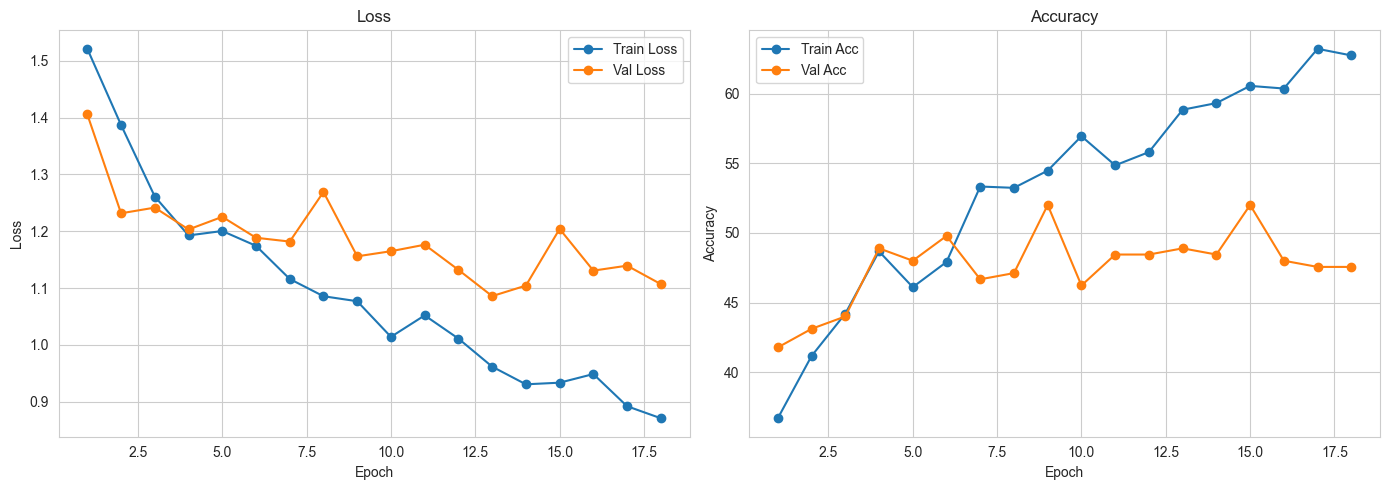

In [7]:
#plot

plot_history(history)

Test Accuracy Global: 51.10%
Accuracy de buffalo: 67.35%
Accuracy de elephant: 42.11%
Accuracy de rhino: 32.73%
Accuracy de zebra: 62.12%


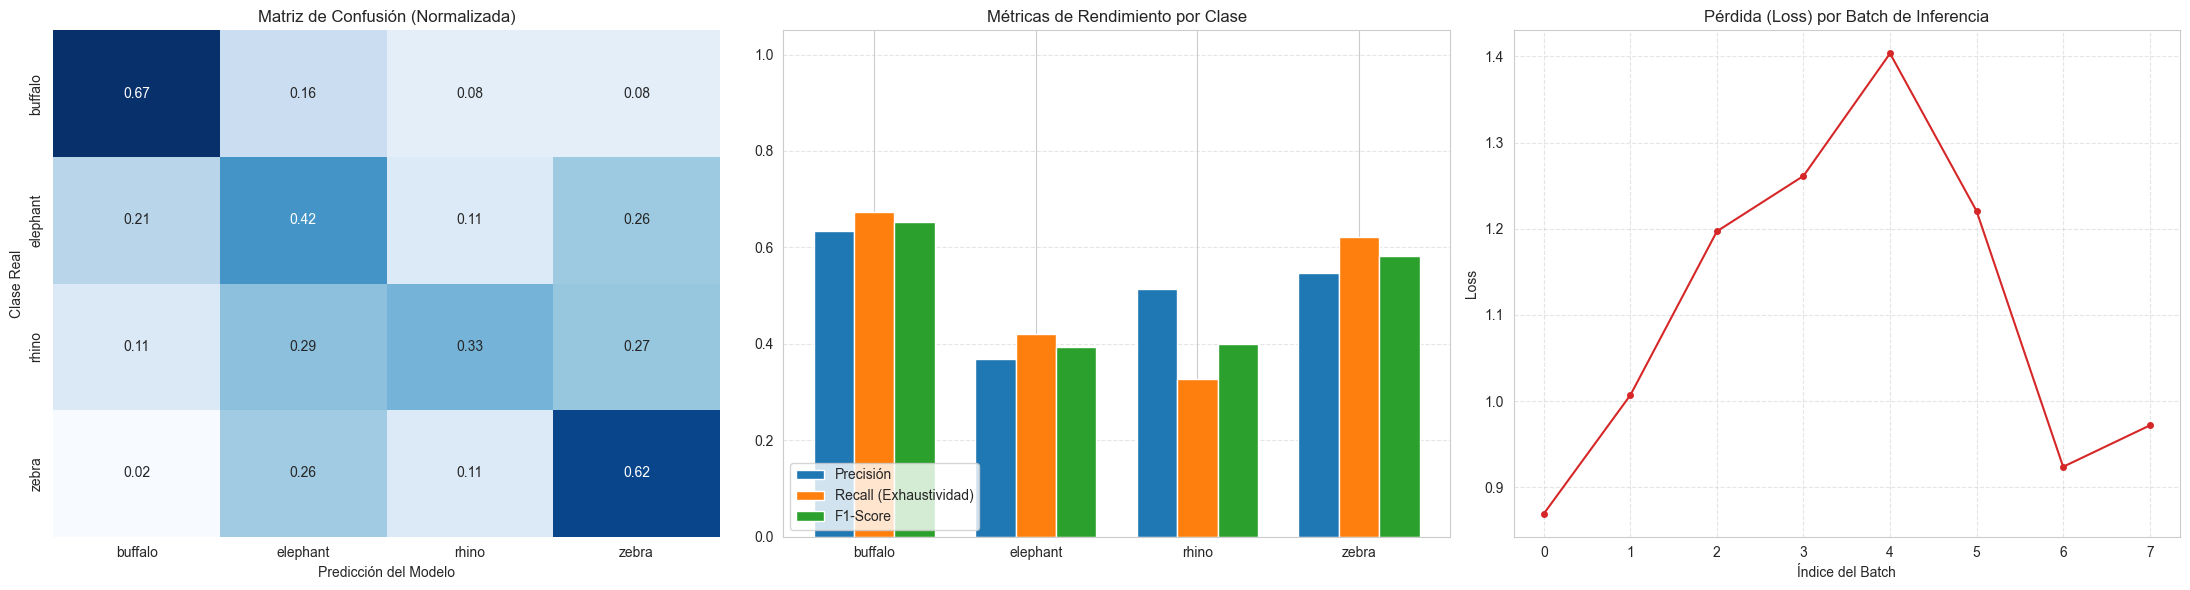


 INFORME DE MÉTRICAS (Classification Report)
              precision    recall  f1-score   support

     buffalo       0.63      0.67      0.65        49
    elephant       0.37      0.42      0.39        57
       rhino       0.51      0.33      0.40        55
       zebra       0.55      0.62      0.58        66

    accuracy                           0.51       227
   macro avg       0.52      0.51      0.51       227
weighted avg       0.51      0.51      0.51       227



In [8]:
#testing

model_tester = Testing(
    model,
    "best_model_mlp.pth",
    device,
    criterion
)

test_loss = model_tester.test(test_loader)